In [1]:
import pandas as pd

df = pd.read_csv("bayut_all_locations_transactions.csv")

In [2]:
df.head()
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 112221 entries, 0 to 112220
Data columns (total 15 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   main_location               112221 non-null  str  
 1   sub_location                112221 non-null  str  
 2   building_project            43127 non-null   str  
 3   location_selected           112221 non-null  str  
 4   date                        112221 non-null  str  
 5   category                    112221 non-null  str  
 6   sub-category                112221 non-null  str  
 7   location_image              112221 non-null  str  
 8   is_off_plan?                112221 non-null  bool 
 9   price(EAD)                  112221 non-null  str  
 10  is_Vacant_at_time_of_sale?  112221 non-null  bool 
 11  type                        112221 non-null  str  
 12  beds                        112102 non-null  str  
 13  built_up(sqft)              112221 non-null  str  
 14 

(112221, 15)

In [3]:
df = df.drop(columns=['location_selected','category', 'sub-category', 'location_image','beds'])

In [4]:
df['date'] = pd.to_datetime(df['date'])

/tmp/ipykernel_99082/3532345252.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


In [5]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

In [6]:
df.columns

Index(['main_location', 'sub_location', 'building_project', 'date',
       'is_off_plan?', 'price(EAD)', 'is_Vacant_at_time_of_sale?', 'type',
       'built_up(sqft)', 'plot(sqft)', 'year', 'month', 'quarter'],
      dtype='str')

In [7]:
df['price(EAD)'] = df['price(EAD)'].astype(str).str.replace(',', '')
df['price(EAD)'] = df['price(EAD)'].astype(float)

df['built_up(sqft)'] = df['built_up(sqft)'].astype(str).str.replace(',', '')
df['built_up(sqft)'] = pd.to_numeric(df['built_up(sqft)'], errors='coerce')

df['plot(sqft)'] = df['plot(sqft)'].astype(str).str.replace(',', '')
df['plot(sqft)'] = pd.to_numeric(df['plot(sqft)'], errors='coerce')

In [8]:
df.isnull().sum()

main_location                      0
sub_location                       0
building_project               69094
date                               0
is_off_plan?                       0
price(EAD)                         0
is_Vacant_at_time_of_sale?         0
type                               0
built_up(sqft)                   134
plot(sqft)                    103425
year                               0
month                              0
quarter                            0
dtype: int64

In [9]:
df.shape

(112221, 13)

In [10]:
rows_to_remove = df[df['built_up(sqft)'].isna() & df['plot(sqft)'].isna()]

removed_rows = rows_to_remove.copy()

df.drop(rows_to_remove.index, inplace=True)

In [11]:
df.shape

(112193, 13)

In [12]:
df.isna().sum()

main_location                      0
sub_location                       0
building_project               69066
date                               0
is_off_plan?                       0
price(EAD)                         0
is_Vacant_at_time_of_sale?         0
type                               0
built_up(sqft)                   106
plot(sqft)                    103397
year                               0
month                              0
quarter                            0
dtype: int64

In [13]:
# built_up(sqft)
df.loc[
    (df['type'] == 'Residential Plot') & (df['built_up(sqft)'].isna()),
    'built_up(sqft)'
] = 0

# building_project
df['building_project'] = df['building_project'].fillna(df['sub_location'])

# plot(sqft)
df.loc[
    (df['type'] == 'Apartment') & (df['plot(sqft)'].isna()),
    'plot(sqft)'
] = 0

In [14]:
# plot(sqft)
df.loc[
    (df['type'] == 'Hotel Apartment') & (df['plot(sqft)'].isna()),
    'plot(sqft)'
] = 0

In [15]:
# plot(sqft)
df.loc[
    (df['type'] == 'Penthouse') & (df['plot(sqft)'].isna()),
    'plot(sqft)'
] = 0

In [16]:
df.isna().sum()

main_location                  0
sub_location                   0
building_project               0
date                           0
is_off_plan?                   0
price(EAD)                     0
is_Vacant_at_time_of_sale?     0
type                           0
built_up(sqft)                71
plot(sqft)                     0
year                           0
month                          0
quarter                        0
dtype: int64

In [17]:
# import pandas as pd
# from IPython.display import display

# # This will temporarily show all rows for just this output
# with pd.option_context('display.max_rows', None):
#     display(df[df['built_up(sqft)'].isnull()])

# # Set globally
# pd.set_option('display.max_rows', None)

# # Now it will print all rows
# df[df['built_up(sqft)'].isnull()]



In [18]:
df['type'].unique()

<StringArray>
['Apartment', 'Villa', 'Hotel Apartment', 'Penthouse', 'Residential Plot']
Length: 5, dtype: str

In [19]:
rows_to_remove = df[df['built_up(sqft)'].isna()]

removed_rows = pd.concat([removed_rows, rows_to_remove], ignore_index=True)

df.drop(rows_to_remove.index, inplace=True)

In [20]:
df['is_off_plan?'] = df['is_off_plan?'].astype(int)
df['is_Vacant_at_time_of_sale?'] = df['is_Vacant_at_time_of_sale?'].astype(int)

In [21]:
df.shape

(112122, 13)

In [22]:
import numpy as np

df['price_per_sqft'] = np.where(
    df['type'] == 'Residential Plot',
    df['price(EAD)'] / df['plot(sqft)'],
    df['price(EAD)'] / df['built_up(sqft)']
)

In [23]:
df.columns

Index(['main_location', 'sub_location', 'building_project', 'date',
       'is_off_plan?', 'price(EAD)', 'is_Vacant_at_time_of_sale?', 'type',
       'built_up(sqft)', 'plot(sqft)', 'year', 'month', 'quarter',
       'price_per_sqft'],
      dtype='str')

In [24]:
df.head()

,main_location,sub_location,building_project,date,is_off_plan?,price(EAD),is_Vacant_at_time_of_sale?,type,built_up(sqft),plot(sqft),year,month,quarter,price_per_sqft
0,Jumeirah Village Circle (JVC),JVC District 10,10 Oxford,2025-09-10,1,1220000.0,0,Apartment,814.0,0.0,2025,9,3,1498.771499
1,Jumeirah Village Circle (JVC),JVC District 10,10 Oxford,2026-02-11,1,740000.0,0,Apartment,409.0,0.0,2026,2,1,1809.290954
2,Jumeirah Village Circle (JVC),JVC District 10,10 Oxford,2025-08-12,1,2165400.0,0,Apartment,1608.0,0.0,2025,8,3,1346.641791
3,Jumeirah Village Circle (JVC),JVC District 10,10 Oxford,2025-12-12,1,775000.0,0,Apartment,423.0,0.0,2025,12,4,1832.151300
4,Jumeirah Village Circle (JVC),JVC District 10,10 Oxford,2026-02-12,1,735000.0,0,Apartment,417.0,0.0,2026,2,1,1762.589928


In [25]:
df.to_csv("final_data.csv", index=False)

In [26]:
df['date'] = pd.to_datetime(df['date'])

df_loc = df.groupby(
    ['sub_location', pd.Grouper(key='date', freq='ME')]
)['price(EAD)'].mean().reset_index()

In [27]:
df_loc

,sub_location,date,price(EAD)
0,11 Hills Park,2025-03-31,9.401010e+05
1,11 Hills Park,2025-04-30,8.828594e+05
2,11 Hills Park,2025-05-31,8.491136e+05
3,11 Hills Park,2025-06-30,9.192666e+05
4,11 Hills Park,2025-07-31,9.333408e+05
...,...,...,...
8126,Zumurud Tower,2025-08-31,7.825000e+05
8127,Zumurud Tower,2025-09-30,9.750000e+05
8128,Zumurud Tower,2025-11-30,9.800000e+05
8129,Zumurud Tower,2025-12-31,8.000000e+05


Train size: (85544, 15)
Test size: (21326, 15)
MAE (price_per_sqft): 123.37916122067114
MAE (price AED): 137650.96154488652


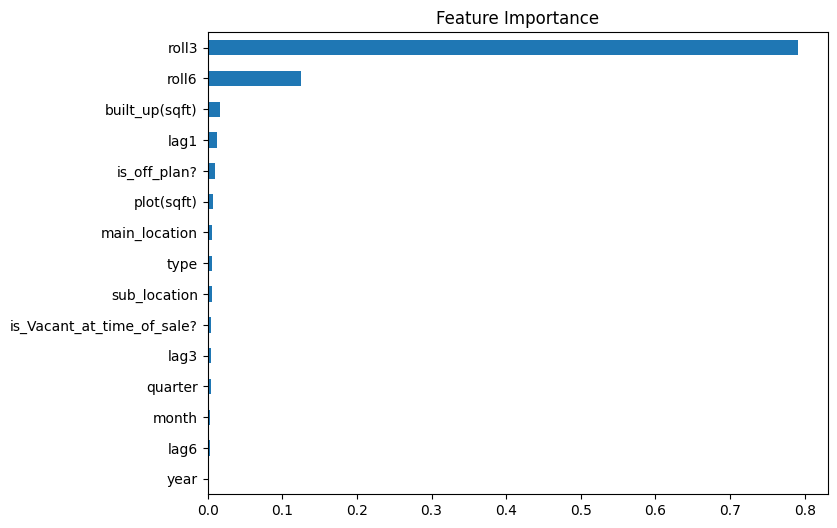

In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor


df = pd.read_csv("final_data.csv")


df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(['sub_location','date'])


df['lag1'] = df.groupby('sub_location')['price_per_sqft'].shift(1)
df['lag3'] = df.groupby('sub_location')['price_per_sqft'].shift(3)
df['lag6'] = df.groupby('sub_location')['price_per_sqft'].shift(6)


df['roll3'] = df.groupby('sub_location')['price_per_sqft'].transform(
    lambda x: x.rolling(3).mean()
)

df['roll6'] = df.groupby('sub_location')['price_per_sqft'].transform(
    lambda x: x.rolling(6).mean()
)


df = df.dropna()


cat_cols = ['main_location','sub_location','type']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

features = [
    'main_location',
    'sub_location',
    'type',
    'built_up(sqft)',
    'plot(sqft)',
    'is_off_plan?',
    'is_Vacant_at_time_of_sale?',
    'year',
    'month',
    'quarter',
    'lag1',
    'lag3',
    'lag6',
    'roll3',
    'roll6'
]

target = 'price_per_sqft'


split_date = df['date'].quantile(0.8)

train = df[df['date'] <= split_date]
test = df[df['date'] > split_date]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


model = XGBRegressor(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)


pred = model.predict(X_test)


mae = mean_absolute_error(y_test, pred)

print("MAE (price_per_sqft):", mae)

predicted_price = pred * X_test['built_up(sqft)']

actual_price = test['price(EAD)']

price_mae = mean_absolute_error(actual_price, predicted_price)

print("MAE (price AED):", price_mae)

import matplotlib.pyplot as plt

importance = model.feature_importances_

feat_importance = pd.Series(importance, index=features)

feat_importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings('ignore')

# 1. Load and Preprocess Data
print("Loading data...")
df = pd.read_csv("final_data.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['sub_location', 'date'])

# Feature Engineering
df['lag1'] = df.groupby('sub_location')['price_per_sqft'].shift(1)
df['lag3'] = df.groupby('sub_location')['price_per_sqft'].shift(3)
df['lag6'] = df.groupby('sub_location')['price_per_sqft'].shift(6)
df['roll3'] = df.groupby('sub_location')['price_per_sqft'].transform(lambda x: x.rolling(3).mean())
df['roll6'] = df.groupby('sub_location')['price_per_sqft'].transform(lambda x: x.rolling(6).mean())
df = df.dropna()

# Encode global categories
for col in ['main_location', 'type']:
    df[col] = LabelEncoder().fit_transform(df[col])

# features = [
#     'main_location', 'type', 'built_up(sqft)', 'plot(sqft)',
#     'is_off_plan?', 'is_Vacant_at_time_of_sale?', 'year', 'month', 'quarter',
#     'lag1', 'lag3', 'lag6', 'roll3', 'roll6'
# ]
features = [
    'type', 'built_up(sqft)', 'plot(sqft)',
    'is_off_plan?', 'is_Vacant_at_time_of_sale?',
    'lag1', 'lag3', 'lag6', 'roll3', 'roll6'
]
target = 'price_per_sqft'

# 2. Train Per-SubLocation Models
sub_locations = sorted(df['sub_location'].unique())
model_results = {}

print(f"Training {len(sub_locations)} sub-location models...")
progress = widgets.IntProgress(value=0, min=0, max=len(sub_locations), description='Training:', bar_style='info')
display(progress)

for sub in sub_locations:
    sub_df = df[df['sub_location'] == sub].copy()
    if len(sub_df) < 50:
        progress.value += 1
        continue
    
    split_date = sub_df['date'].quantile(0.8)
    train_data = sub_df[sub_df['date'] <= split_date].copy()
    test_data = sub_df[sub_df['date'] > split_date].copy()
    
    if len(train_data) < 10 or len(test_data) < 5:
        progress.value += 1
        continue
        
    model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, n_jobs=-1, random_state=42)
    model.fit(train_data[features], train_data[target])
    
    train_data.loc[:, 'pred'] = model.predict(train_data[features])
    test_data.loc[:, 'pred'] = model.predict(test_data[features])
    
    metrics = {
        'train_mae': mean_absolute_error(train_data[target], train_data['pred']),
        'test_mae': mean_absolute_error(test_data[target], test_data['pred']),
        'train_rmse': np.sqrt(mean_squared_error(train_data[target], train_data['pred'])),
        'test_rmse': np.sqrt(mean_squared_error(test_data[target], test_data['pred'])),
        'test_r2': r2_score(test_data[target], test_data['pred'])
    }
    
    model_results[sub] = {'train': train_data, 'test': test_data, 'metrics': metrics}
    progress.value += 1

progress.close()
print(f"Successfully trained {len(model_results)} models.")

# 3. Interactive Dashboard
output = widgets.Output()

def update_dashboard(sub_name):
    with output:
        clear_output(wait=True)
        res = model_results[sub_name]
        train_res, test_res, m = res['train'], res['test'], res['metrics']
        
        def to_monthly(d):
            return d.groupby(d['date'].dt.to_period('M')).agg({'date':'first', target:'mean', 'pred':'mean'}).reset_index(drop=True)
        
        train_m, test_m = to_monthly(train_res), to_monthly(test_res)
        
        display(widgets.HTML(f"""
            <div style="display: flex; gap: 15px; font-family: sans-serif; padding: 10px; background: #f1f3f5; border-radius: 12px; margin-bottom: 25px;">
                <div style="flex: 1; padding: 15px; background: white; border-radius: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); text-align: center;">
                    <h4 style="margin: 0; color: #6c757d; font-size: 11px; text-transform: uppercase;">Train MAE</h4>
                    <p style="margin: 8px 0 0; font-size: 22px; font-weight: 700; color: #4361EE;">{m['train_mae']:,.1f}</p>
                </div>
                <div style="flex: 1; padding: 15px; background: white; border-radius: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); text-align: center;">
                    <h4 style="margin: 0; color: #6c757d; font-size: 11px; text-transform: uppercase;">Test MAE</h4>
                    <p style="margin: 8px 0 0; font-size: 22px; font-weight: 700; color: #F77F00;">{m['test_mae']:,.1f}</p>
                </div>
                <div style="flex: 1; padding: 15px; background: white; border-radius: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); text-align: center;">
                    <h4 style="margin: 0; color: #6c757d; font-size: 11px; text-transform: uppercase;">Test RMSE</h4>
                    <p style="margin: 8px 0 0; font-size: 22px; font-weight: 700; color: #E63946;">{m['test_rmse']:,.1f}</p>
                </div>
                <div style="flex: 1; padding: 15px; background: white; border-radius: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); text-align: center;">
                    <h4 style="margin: 0; color: #6c757d; font-size: 11px; text-transform: uppercase;">Test R² Score</h4>
                    <p style="margin: 8px 0 0; font-size: 22px; font-weight: 700; color: #2ECC71;">{m['test_r2']:.3f}</p>
                </div>
            </div>
        """))

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=train_m['date'], y=train_m[target], name='Actual (Train)', line=dict(color='#4361EE', width=3)))
        fig.add_trace(go.Scatter(x=test_m['date'], y=test_m[target], name='Actual (Test)', line=dict(color='#F77F00', width=3)))
        fig.add_trace(go.Scatter(x=train_m['date'], y=train_m['pred'], name='Pred (Train)', line=dict(color='#A8DADC', width=2.5, dash='dot')))
        fig.add_trace(go.Scatter(x=test_m['date'], y=test_m[pred], name='Pred (Test)', line=dict(color='#E63946', width=2.5, dash='dot')))
        
        fig.update_layout(
            title=f"Price per Sqft Trend: Actual vs Predicted - {sub_name}",
            xaxis_title="Date", yaxis_title="AED / Sqft", height=500,
            template='plotly_white', hovermode='x unified',
            legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
        )
        fig.show()

dropdown = widgets.Dropdown(options=sorted(model_results.keys()), description='<b>Sub Location:</b>', style={'description_width': 'initial'})
widgets.interactive(update_dashboard, sub_name=dropdown)

display(widgets.VBox([
    widgets.HTML("<h2 style='font-family: sans-serif; color: #2c3e50; margin-bottom: 10px;'>🏙️ Sub-Location Prediction Dashboard</h2>"),
    dropdown, output
]))

if model_results:
    update_dashboard(dropdown.value)



Loading data...
Training 828 sub-location models...


IntProgress(value=0, bar_style='info', description='Training:', max=828)

Successfully trained 347 models.


In [30]:
# ======================================
# 1. Imports
# ======================================
import pandas as pd
import numpy as np
import joblib
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.preprocessing import LabelEncoder

# ======================================
# 2. Load Model + Data
# ======================================
model   = joblib.load("real_estate_price_model.pkl")
encoder = joblib.load("location_encoder.pkl")   # the 'le' from training

df = pd.read_csv("final_data.csv")
df["date"] = pd.to_datetime(df["date"])

if "price_per_sqft" not in df.columns:
    df["price_per_sqft"] = df["price(EAD)"] / df["built_up(sqft)"]

# ======================================
# 3. Recreate Monthly Aggregation (same as training)
# ======================================
df_month = df.groupby(
    ['sub_location', 'year', 'month']
).agg({
    'price_per_sqft': 'mean',
    'built_up(sqft)': 'mean',
    'plot(sqft)':     'mean'
}).reset_index()

df_month['date'] = pd.to_datetime(
    df_month['year'].astype(str) + '-' +
    df_month['month'].astype(str) + '-01'
)

df_month = df_month.sort_values(['sub_location', 'date'])

# Lag features on monthly data
df_month['lag1'] = df_month.groupby('sub_location')['price_per_sqft'].shift(1)
df_month['lag3'] = df_month.groupby('sub_location')['price_per_sqft'].shift(3)
df_month['lag6'] = df_month.groupby('sub_location')['price_per_sqft'].shift(6)

df_month['roll3'] = df_month.groupby('sub_location')['price_per_sqft'].transform(
    lambda x: x.rolling(3).mean()
)
df_month['roll6'] = df_month.groupby('sub_location')['price_per_sqft'].transform(
    lambda x: x.rolling(6).mean()
)

df_month = df_month.dropna()

# Keep original names for UI
df_month['sub_location_name'] = df_month['sub_location']

# Filter only known locations
df_month = df_month[df_month['sub_location'].isin(encoder.classes_)]

# ======================================
# 4. Cascading Widgets
# ======================================
all_main = df[df['sub_location'].isin(encoder.classes_)][['main_location','sub_location']].drop_duplicates()

main_locations = sorted(all_main['main_location'].unique())

main_dropdown = widgets.Dropdown(
    options=main_locations,
    description="Location:",
    layout=widgets.Layout(width="400px")
)

def get_sub_locs(main):
    return sorted(all_main[all_main['main_location'] == main]['sub_location'].unique())

sub_dropdown = widgets.Dropdown(
    options=get_sub_locs(main_locations[0]),
    description="Sub-Loc:",
    layout=widgets.Layout(width="400px")
)

def on_main_change(change):
    new_subs = get_sub_locs(change["new"])
    sub_dropdown.options = new_subs
    sub_dropdown.value   = new_subs[0]

main_dropdown.observe(on_main_change, names="value")

# Size and plot sliders — pre-fill from data average
def get_avg(col, sub):
    vals = df_month[df_month['sub_location_name'] == sub][col]
    return int(vals.mean()) if not vals.empty else 800

size_slider = widgets.IntSlider(value=800, min=200, max=5000, step=50, description="Built-up sqft")
plot_slider = widgets.IntSlider(value=0,   min=0,  max=10000, step=50, description="Plot sqft")

def on_sub_change(change):
    sub = change["new"]
    size_slider.value = get_avg('built_up(sqft)', sub)
    plot_slider.value = get_avg('plot(sqft)', sub)

sub_dropdown.observe(on_sub_change, names="value")

year_dropdown  = widgets.Dropdown(options=sorted(df['year'].unique()), description="Year")
month_dropdown = widgets.Dropdown(options=list(range(1, 13)),          description="Month")

predict_btn = widgets.Button(
    description="Predict Property Price",
    button_style="success",
    icon="calculator",
    layout=widgets.Layout(width="260px")
)

output = widgets.Output()

# ======================================
# 5. Prediction Function
# ======================================
def predict_price(b):
    with output:
        clear_output(wait=True)
        try:
            sub_loc = sub_dropdown.value

            # Get monthly history for this location
            history = df_month[df_month['sub_location_name'] == sub_loc].sort_values('date')
            print(f"📊 Monthly data points: {len(history)}")

            if len(history) < 6:
                print("❌ Not enough historical data (need at least 6 months)")
                return

            price_series = history['price_per_sqft'].values
            lag1  = price_series[-1]
            lag3  = price_series[-3]
            lag6  = price_series[-6]
            roll3 = np.mean(price_series[-3:])
            roll6 = np.mean(price_series[-6:])

            loc_encoded = encoder.transform([sub_loc])[0]

            # ✅ Exact 10 features matching training
            # [sub_location, built_up(sqft), plot(sqft), year, month, lag1, lag3, lag6, roll3, roll6]
            features_vec = np.array([[
                loc_encoded,
                size_slider.value,
                plot_slider.value,
                year_dropdown.value,
                month_dropdown.value,
                lag1, lag3, lag6,
                roll3, roll6
            ]])

            pred            = model.predict(features_vec)[0]
            estimated_price = pred * size_slider.value

            print("─" * 44)
            print(f"📍 Location      : {main_dropdown.value}")
            print(f"📍 Sub-Location  : {sub_loc}")
            print(f"📐 Built-up      : {size_slider.value:,} sqft")
            print(f"🏗️  Plot           : {plot_slider.value:,} sqft")
            print(f"📅 Period         : {month_dropdown.value}/{year_dropdown.value}")
            print("─" * 44)
            print(f"💰 Price/Sqft    : {pred:,.2f} AED")
            print(f"🏡 Total Price   : {estimated_price:,.0f} AED")
            print("─" * 44)

        except Exception as e:
            print(f"❌ Error: {type(e).__name__}: {e}")

predict_btn.on_click(predict_price)

# ======================================
# 6. Layout
# ======================================
ui = widgets.VBox([
    widgets.HTML("<h2>🏠 Real Estate Price Prediction Dashboard</h2>"),
    widgets.HTML("<b>📍 Location</b>"),
    main_dropdown,
    sub_dropdown,
    widgets.HTML("<b>🏠 Property Details</b>"),
    size_slider,
    plot_slider,
    widgets.HBox([year_dropdown, month_dropdown]),
    widgets.HTML("<br>"),
    predict_btn,
    widgets.HTML("<hr>"),
    output
])

display(ui)


IndexError: list index out of range

In [ ]:
import joblib

# Save model
joblib.dump(model, "real_estate_price_model.pkl")

# Save encoder
joblib.dump(le, "location_encoder.pkl")

print("Model and encoder saved successfully.")

Model and encoder saved successfully.


In [ ]:
# ======================================
# 1. Imports
# ======================================
import pandas as pd
import numpy as np
import joblib
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.preprocessing import LabelEncoder

# ======================================
# 2. Load Model + Data
# ======================================
model   = joblib.load("real_estate_price_model.pkl")
encoder = joblib.load("location_encoder.pkl")

df = pd.read_csv("final_data.csv")
df["date"] = pd.to_datetime(df["date"])

if "price_per_sqft" not in df.columns:
    df["price_per_sqft"] = df["price(EAD)"] / df["built_up(sqft)"]

df = df[df["sub_location"].isin(encoder.classes_)]

type_le = LabelEncoder().fit(df["type"].dropna())

# ======================================
# 3. Cascading Widgets
# ======================================

# Level 1: Main Location
main_locations = sorted(df["main_location"].unique())
main_location_dropdown = widgets.Dropdown(
    options=main_locations,
    description="Location:",
    layout=widgets.Layout(width="400px")
)

# Level 2: Sub Location (filtered by main)
def get_sub_locations(main_loc):
    return sorted(df[df["main_location"] == main_loc]["sub_location"].unique())

sub_location_dropdown = widgets.Dropdown(
    options=get_sub_locations(main_locations[0]),
    description="Sub-Loc:",
    layout=widgets.Layout(width="400px")
)

# Level 3: Type (filtered by sub_location)
def get_types(sub_loc):
    types = df[df["sub_location"] == sub_loc]["type"].dropna().unique()
    return ["All"] + sorted(types)

type_dropdown = widgets.Dropdown(
    options=get_types(sub_location_dropdown.options[0]),
    description="Type:"
)

# Cascade observers
def on_main_location_change(change):
    new_subs = get_sub_locations(change["new"])
    sub_location_dropdown.options = new_subs
    sub_location_dropdown.value   = new_subs[0]

def on_sub_location_change(change):
    new_types = get_types(change["new"])
    type_dropdown.options = new_types
    type_dropdown.value   = new_types[0]

main_location_dropdown.observe(on_main_location_change, names="value")
sub_location_dropdown.observe(on_sub_location_change,   names="value")

# Other inputs
size_slider    = widgets.IntSlider(value=800, min=200, max=5000, step=50, description="Built-up sqft")
year_dropdown  = widgets.Dropdown(options=sorted(df["year"].unique()), description="Year")
month_dropdown = widgets.Dropdown(options=list(range(1, 13)), description="Month")

predict_btn = widgets.Button(
    description="Predict Property Price",
    button_style="success",
    icon="calculator",
    layout=widgets.Layout(width="260px")
)

output = widgets.Output()

# ======================================
# 4. Prediction Function
# ======================================
def predict_price(b):
    with output:
        clear_output(wait=True)
        try:
            main_loc  = main_location_dropdown.value
            sub_loc   = sub_location_dropdown.value
            prop_type = type_dropdown.value

            subset = df[(df["main_location"] == main_loc) & (df["sub_location"] == sub_loc)].copy()
            if prop_type != "All":
                subset = subset[subset["type"] == prop_type]

            subset = subset.sort_values("date")
            print(f"📊 Data points found: {len(subset)}")

            if len(subset) < 6:
                print("❌ Not enough historical data (need at least 6 rows)")
                return

            price_series = subset["price_per_sqft"].values
            lag1  = price_series[-1]
            lag3  = price_series[-3]
            lag6  = price_series[-6]
            roll3 = np.mean(price_series[-3:])
            roll6 = np.mean(price_series[-6:])

            loc_encoded = encoder.transform([sub_loc])[0]

            if prop_type != "All" and prop_type in type_le.classes_:
                type_encoded = type_le.transform([prop_type])[0]
            else:
                type_encoded = 0

            # ✅ 10 features — matches the saved model exactly
            # [sub_location, built_up(sqft), type, year, month, lag1, lag3, lag6, roll3, roll6]
            features_vec = np.array([[
                loc_encoded,
                size_slider.value,
                type_encoded,
                year_dropdown.value,
                month_dropdown.value,
                lag1, lag3, lag6,
                roll3, roll6
            ]])

            pred            = model.predict(features_vec)[0]
            estimated_price = pred * size_slider.value

            print("─" * 42)
            print(f"📍 Location     : {main_loc}")
            print(f"📍 Sub-Location : {sub_loc}")
            print(f"🏠 Type         : {prop_type}")
            print(f"📐 Built-up     : {size_slider.value} sqft")
            print(f"📅 Period       : {month_dropdown.value}/{year_dropdown.value}")
            print("─" * 42)
            print(f"💰 Price/Sqft   : {pred:,.2f} AED")
            print(f"🏡 Total Price  : {estimated_price:,.0f} AED")
            print("─" * 42)

        except Exception as e:
            print(f"❌ Error: {type(e).__name__}: {e}")

predict_btn.on_click(predict_price)

# ======================================
# 5. Layout
# ======================================
ui = widgets.VBox([
    widgets.HTML("<h2>🏠 Real Estate Price Prediction Dashboard</h2>"),
    widgets.HTML("<b>📍 Location</b>"),
    main_location_dropdown,
    sub_location_dropdown,
    type_dropdown,
    widgets.HTML("<b>🏠 Property Details</b>"),
    size_slider,
    widgets.HBox([year_dropdown, month_dropdown]),
    widgets.HTML("<br>"),
    predict_btn,
    widgets.HTML("<hr>"),
    output
])

display(ui)



IndexError: list index out of range

In [ ]:
# ======================================
# 1. Import Libraries
# ======================================
import numpy as np
import pandas as pd
import joblib
import ipywidgets as widgets
from IPython.display import display

# ======================================
# 2. Load Model and Encoder
# ======================================
model = joblib.load("real_estate_price_model.pkl")
encoder = joblib.load("location_encoder.pkl")

# Load dataset (used only for dropdown values)
df = pd.read_csv("final_data.csv")

# ======================================
# 3. Prepare Dropdown Values
# ======================================

# Only locations known by encoder (prevents unseen label error)
locations = list(encoder.classes_)

years = sorted(df["year"].unique())

months = list(range(1, 13))

# ======================================
# 4. Create Widgets
# ======================================

sub_location = widgets.Dropdown(
    options=locations,
    description="Location:",
    layout=widgets.Layout(width="400px")
)

built_up = widgets.FloatText(
    value=800,
    description="Built-up sqft:"
)

plot_area = widgets.FloatText(
    value=0,
    description="Plot sqft:"
)

year = widgets.Dropdown(
    options=years,
    description="Year:"
)

month = widgets.Dropdown(
    options=months,
    description="Month:"
)

lag1 = widgets.FloatText(value=1800, description="Lag1:")
lag3 = widgets.FloatText(value=1750, description="Lag3:")
lag6 = widgets.FloatText(value=1700, description="Lag6:")

roll3 = widgets.FloatText(value=1780, description="Roll3:")
roll6 = widgets.FloatText(value=1760, description="Roll6:")

button = widgets.Button(
    description="Predict Price",
    button_style="success"
)

output = widgets.Output()

# ======================================
# 5. Prediction Function
# ======================================

def predict(b):

    with output:
        output.clear_output()

        try:
            loc_encoded = encoder.transform([sub_location.value])[0]

            features = np.array([[
                loc_encoded,
                built_up.value,
                plot_area.value,
                year.value,
                month.value,
                lag1.value,
                lag3.value,
                lag6.value,
                roll3.value,
                roll6.value
            ]])

            pred = model.predict(features)[0]

            price = pred * built_up.value

            print("Location:", sub_location.value)
            print(f"Predicted Price per Sqft: {pred:.2f}")
            print(f"Estimated Property Price: {price:,.0f} AED")

        except Exception as e:
            print("Prediction Error:", e)

button.on_click(predict)

# ======================================
# 6. Display GUI
# ======================================

ui = widgets.VBox([
    sub_location,
    built_up,
    plot_area,
    year,
    month,
    lag1,
    lag3,
    lag6,
    roll3,
    roll6,
    button,
    output
])

display(ui)